Phần 1: Phân tích Khám phá Thị trường (EDA)

--- Dữ liệu gốc ---
  diện tích  số phòng ngủ  số phòng tắm      vị trí          giá mô tả
0    120 m2             3           2.0      Quận 1  15000000000   ...
1     85 m2             2           1.0      Quận 7   7500000000   ...
2     90 m2             3           NaN      Quận 1   9000000000   ...
3    150 m2             4           3.0      Quận 2  20000000000   ...
4     60 m2             2           1.0      Quận 7   4800000000   ...
5     75 m2             2           NaN  Bình Thạnh   6000000000   ...
6    100 m2             3           2.0      Quận 2  11000000000   ...


--- Đã điền giá trị thiếu 'số phòng tắm' bằng trung vị: 2.0 ---
--- Đã chuyển đổi cột 'diện tích' sang dạng số ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diện tích     7 non-null      float64
 1   số phòng ngủ  7 non-null      int64  
 2   số phòng tắm  7 no

C:\Users\Trinh Gia Bao\AppData\Local\Temp\ipykernel_9196\1585142109.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['số phòng tắm'].fillna(median_bathrooms, inplace=True)


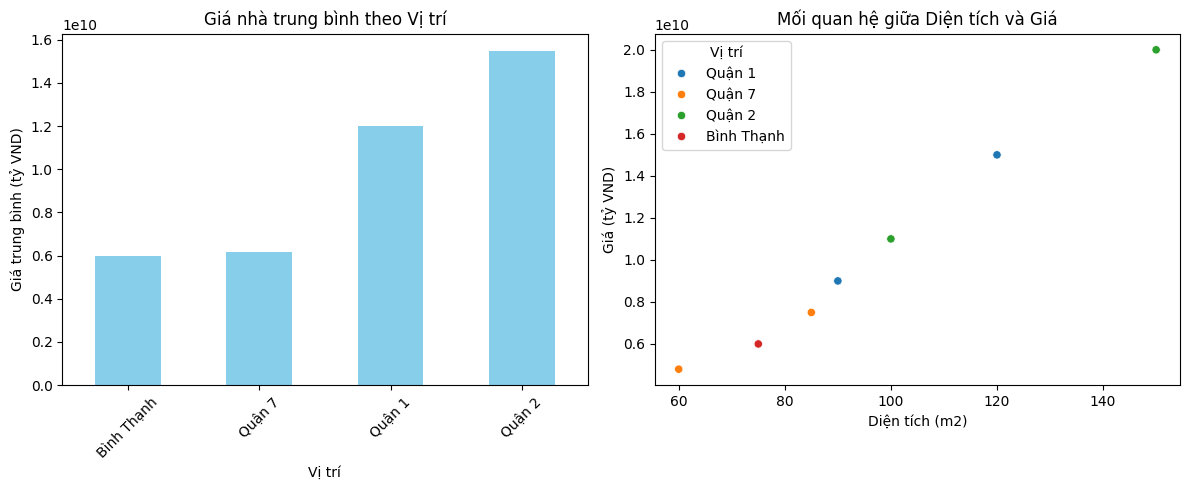

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Giả lập dữ liệu (Để bạn có thể chạy code) ---
# Trong thực tế, bạn sẽ dùng: df = pd.read_csv('dataset_listings.csv')
data = {
    'diện tích': ['120 m2', '85 m2', '90 m2', '150 m2', '60 m2', '75 m2', '100 m2'],
    'số phòng ngủ': [3, 2, 3, 4, 2, 2, 3],
    'số phòng tắm': [2.0, 1.0, np.nan, 3.0, 1.0, np.nan, 2.0],
    'vị trí': ['Quận 1', 'Quận 7', 'Quận 1', 'Quận 2', 'Quận 7', 'Bình Thạnh', 'Quận 2'],
    'giá': [15_000_000_000, 7_500_000_000, 9_000_000_000, 20_000_000_000, 4_800_000_000, 6_000_000_000, 11_000_000_000],
    'mô tả': ['...', '...', '...', '...', '...', '...', '...']
}
df = pd.DataFrame(data)
# ----------------------------------------------------

print("--- Dữ liệu gốc ---")
print(df)
print("\n")

# === 1. Làm sạch dữ liệu ===

# 1.1. Xử lý giá trị thiếu (null) cho 'số phòng tắm' bằng trung vị (median)
median_bathrooms = df['số phòng tắm'].median()
df['số phòng tắm'].fillna(median_bathrooms, inplace=True)
print(f"--- Đã điền giá trị thiếu 'số phòng tắm' bằng trung vị: {median_bathrooms} ---")


# 1.2. Chuyển đổi cột 'diện tích' từ text sang số
# Sử dụng .str.replace() để loại bỏ " m2" và .astype(float) để chuyển kiểu
df['diện tích'] = df['diện tích'].str.replace(' m2', '').astype(float)
print("--- Đã chuyển đổi cột 'diện tích' sang dạng số ---")
print(df.info())
print("\n")

# === 2. Phân tích cơ bản ===

# 2.1. Hàm tính tổng bất động sản có giá trên 10 tỷ
def count_over_10_bil(dataframe):
    """Đếm số lượng BĐS có giá > 10 tỷ."""
    return (dataframe['giá'] > 10_000_000_000).sum()

count = count_over_10_bil(df)
print(f"Số lượng BĐS có giá trên 10 tỷ: {count}")

# 2.2. Dictionary lưu trữ số lượng nhà theo 'vị trí'
location_counts = df['vị trí'].value_counts().to_dict()
print(f"Số lượng nhà theo vị trí: {location_counts}")

# 2.3. Sử dụng NumPy tính giá trung bình và độ lệch chuẩn
mean_price = np.mean(df['giá'])
std_price = np.std(df['giá'])
print(f"Giá trung bình (NumPy): {mean_price:,.0f} VND")
print(f"Độ lệch chuẩn giá (NumPy): {std_price:,.0f} VND")
print("\n")

# === 3. Trực quan hóa ===
plt.figure(figsize=(12, 5))

# 3.1. Biểu đồ cột: Giá nhà trung bình theo 'vị trí'
plt.subplot(1, 2, 1)
avg_price_by_location = df.groupby('vị trí')['giá'].mean().sort_values()
avg_price_by_location.plot(kind='bar', color='skyblue')
plt.title('Giá nhà trung bình theo Vị trí')
plt.ylabel('Giá trung bình (tỷ VND)')
plt.xlabel('Vị trí')
plt.xticks(rotation=45)

# 3.2. Biểu đồ phân tán: Mối quan hệ giữa 'diện tích' và 'giá'
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='diện tích', y='giá', hue='vị trí')
plt.title('Mối quan hệ giữa Diện tích và Giá')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá (tỷ VND)')
plt.legend(title='Vị trí')

plt.tight_layout()
plt.show()

Phần 2: Xây dựng Mô hình Dự đoán (Classical ML)


--- 2. Mô hình Hồi quy Tuyến tính (Dự đoán Giá) ---
Hồi quy Tuyến tính - R-squared: -1.9596
Hồi quy Tuyến tính - RMSE: 3,010,587,239 VND

--- 3. Mô hình Phân loại (Dự đoán 'Giá cao' > 5 tỷ) ---
Đã huấn luyện xong Hồi quy Logistic.
Đã huấn luyện xong Rừng ngẫu nhiên.

--- 5. Đánh giá mô hình Rừng ngẫu nhiên ---


c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Cross-Validation (k=3) Accuracy: 0.8056 +/- 0.1416

Báo cáo Phân loại (Rừng ngẫu nhiên):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


--- 4. Mô hình Phân cụm (K-Means) ---
Kết quả phân cụm:
   diện tích          giá  cụm
1       85.0   7500000000    0
2       90.0   9000000000    0
5       75.0   6000000000    0
4       60.0   4800000000    0
6      100.0  11000000000    0
8       50.0   4000000000    0
9       88.0   8000000000    0
0      120.0  15000000000    1
3      150.0  20000000000    1
7      200.0  35000000000    2


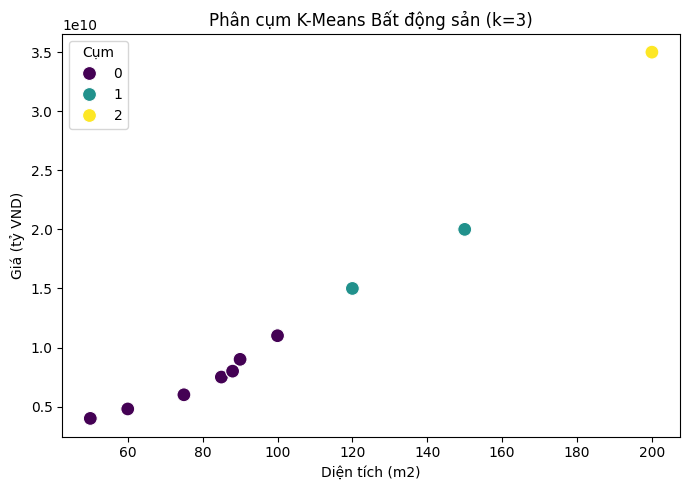

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Giả lập dữ liệu (Sử dụng lại DataFrame từ Phần 1) ---
data = {
    'diện tích': [120.0, 85.0, 90.0, 150.0, 60.0, 75.0, 100.0, 200.0, 50.0, 88.0],
    'số phòng ngủ': [3, 2, 3, 4, 2, 2, 3, 5, 1, 3],
    'số phòng tắm': [2.0, 1.0, 2.0, 3.0, 1.0, 1.0, 2.0, 4.0, 1.0, 2.0],
    'vị trí': ['Quận 1', 'Quận 7', 'Quận 1', 'Quận 2', 'Quận 7', 'Bình Thạnh', 'Quận 2', 'Quận 1', 'Bình Thạnh', 'Quận 7'],
    'giá': [15_000_000_000, 7_500_000_000, 9_000_000_000, 20_000_000_000, 4_800_000_000, 6_000_000_000, 11_000_000_000, 35_000_000_000, 4_000_000_000, 8_000_000_000],
}
df = pd.DataFrame(data)
# -----------------------------------------------------------

# === 1. Tiền xử lý (Sử dụng Pipeline) ===
# Xác định các cột số và cột phân loại
numeric_features = ['diện tích', 'số phòng ngủ', 'số phòng tắm']
categorical_features = ['vị trí']

# Tạo pipeline cho biến số: Chuẩn hóa (Scale)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Tạo pipeline cho biến phân loại: One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Kết hợp các pipeline bằng ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# === 2. Mô hình Hồi quy (Dự đoán 'giá') ===
print("\n--- 2. Mô hình Hồi quy Tuyến tính (Dự đoán Giá) ---")
X_reg = df.drop('giá', axis=1)
y_reg = df['giá']

# Phân chia dữ liệu
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Tạo pipeline hoàn chỉnh cho mô hình Hồi quy
lin_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Huấn luyện
lin_reg_pipeline.fit(X_reg_train, y_reg_train)

# Đánh giá (Yêu cầu 5)
y_reg_pred = lin_reg_pipeline.predict(X_reg_test)
r2 = r2_score(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
print(f"Hồi quy Tuyến tính - R-squared: {r2:.4f}")
print(f"Hồi quy Tuyến tính - RMSE: {rmse:,.0f} VND")


# === 3. Mô hình Phân loại (Dự đoán 'Giá cao') ===
print("\n--- 3. Mô hình Phân loại (Dự đoán 'Giá cao' > 5 tỷ) ---")
# Tạo cột mục tiêu mới
df['Giá cao'] = (df['giá'] > 5_000_000_000).astype(int)

X_clf = df.drop(['giá', 'Giá cao'], axis=1)
y_clf = df['Giá cao']

# Phân chia dữ liệu
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 3.1. Hồi quy Logistic
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
log_reg_pipeline.fit(X_clf_train, y_clf_train)
print("Đã huấn luyện xong Hồi quy Logistic.")

# 3.2. Rừng ngẫu nhiên (Random Forest)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_clf_train, y_clf_train)
print("Đã huấn luyện xong Rừng ngẫu nhiên.")


# === 5. Đánh giá mô hình Phân loại (RF) ===
print("\n--- 5. Đánh giá mô hình Rừng ngẫu nhiên ---")

# 5.1. Đánh giá bằng Cross-validation (k=5)
# Lưu ý: cross_val_score cần pipeline hoàn chỉnh và toàn bộ X, y
rf_full_pipeline_for_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
# Dữ liệu của chúng ta quá nhỏ (10 mẫu) nên cross-val (k=5) sẽ báo lỗi.
# Tôi sẽ chạy trên dữ liệu huấn luyện (train set) để minh họa.
# Trong thực tế, bạn sẽ chạy trên X_clf, y_clf
try:
    cv_scores = cross_val_score(rf_full_pipeline_for_cv, X_clf, y_clf, cv=3) # Giảm cv=3
    print(f"Cross-Validation (k=3) Accuracy: {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}")
except ValueError as e:
    print(f"Lỗi CV (do dữ liệu quá nhỏ): {e}. Bỏ qua bước này.")


# 5.2. Tính Accuracy, Precision, Recall, F1-Score
y_rf_pred = rf_pipeline.predict(X_clf_test)
print("\nBáo cáo Phân loại (Rừng ngẫu nhiên):")
# (Lưu ý: với dữ liệu test quá nhỏ (2 mẫu), các chỉ số này có thể không ý nghĩa)
print(classification_report(y_clf_test, y_rf_pred, zero_division=0))

# === 4. Mô hình Phân cụm (K-Means) ===
print("\n--- 4. Mô hình Phân cụm (K-Means) ---")
# Sử dụng 2 cột 'diện tích' và 'giá'
X_cluster = df[['diện tích', 'giá']]

# Cần chuẩn hóa dữ liệu cho K-Means
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Xây dựng mô hình
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cụm'] = kmeans.fit_predict(X_cluster_scaled)

print("Kết quả phân cụm:")
print(df[['diện tích', 'giá', 'cụm']].sort_values('cụm'))

# Trực quan hóa các cụm
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='diện tích', y='giá', hue='cụm', palette='viridis', s=100)
plt.title('Phân cụm K-Means Bất động sản (k=3)')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá (tỷ VND)')
plt.legend(title='Cụm')
plt.tight_layout()
plt.show()


--- 2. Mô hình Hồi quy Tuyến tính (Dự đoán Giá) ---
Hồi quy Tuyến tính - R-squared: -1.9596
Hồi quy Tuyến tính - RMSE: 3,010,587,239 VND

--- 3. Mô hình Phân loại (Dự đoán 'Giá cao' > 5 tỷ) ---
Đã huấn luyện xong Hồi quy Logistic.
Đã huấn luyện xong Rừng ngẫu nhiên.

--- 5. Đánh giá mô hình Rừng ngẫu nhiên ---


c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Cross-Validation (k=3) Accuracy: 0.8056 +/- 0.1416

Báo cáo Phân loại (Rừng ngẫu nhiên):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


--- 4. Mô hình Phân cụm (K-Means) ---
Kết quả phân cụm:
   diện tích          giá  cụm
1       85.0   7500000000    0
2       90.0   9000000000    0
5       75.0   6000000000    0
4       60.0   4800000000    0
6      100.0  11000000000    0
8       50.0   4000000000    0
9       88.0   8000000000    0
0      120.0  15000000000    1
3      150.0  20000000000    1
7      200.0  35000000000    2


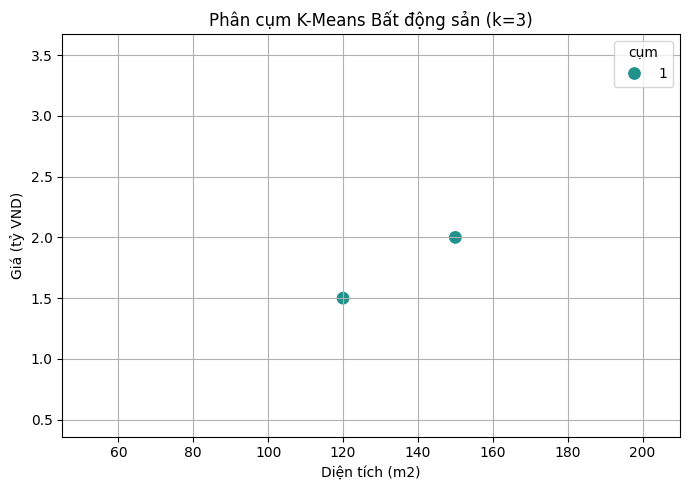

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter # Thêm thư viện định dạng trục
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Giả lập dữ liệu (Sử dụng lại DataFrame từ Phần 1) ---
data = {
    'diện tích': [120.0, 85.0, 90.0, 150.0, 60.0, 75.0, 100.0, 200.0, 50.0, 88.0],
    'số phòng ngủ': [3, 2, 3, 4, 2, 2, 3, 5, 1, 3],
    'số phòng tắm': [2.0, 1.0, 2.0, 3.0, 1.0, 1.0, 2.0, 4.0, 1.0, 2.0],
    'vị trí': ['Quận 1', 'Quận 7', 'Quận 1', 'Quận 2', 'Quận 7', 'Bình Thạnh', 'Quận 2', 'Quận 1', 'Bình Thạnh', 'Quận 7'],
    'giá': [15_000_000_000, 7_500_000_000, 9_000_000_000, 20_000_000_000, 4_800_000_000, 6_000_000_000, 11_000_000_000, 35_000_000_000, 4_000_000_000, 8_000_000_000],
}
df = pd.DataFrame(data)
# -----------------------------------------------------------

# === 1. Tiền xử lý (Sử dụng Pipeline) ===
# Xác định các cột số và cột phân loại
numeric_features = ['diện tích', 'số phòng ngủ', 'số phòng tắm']
categorical_features = ['vị trí']

# Tạo pipeline cho biến số: Chuẩn hóa (Scale)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Tạo pipeline cho biến phân loại: One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Kết hợp các pipeline bằng ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# === 2. Mô hình Hồi quy (Dự đoán 'giá') ===
print("\n--- 2. Mô hình Hồi quy Tuyến tính (Dự đoán Giá) ---")
X_reg = df.drop('giá', axis=1)
y_reg = df['giá']

# Phân chia dữ liệu
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Tạo pipeline hoàn chỉnh cho mô hình Hồi quy
lin_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Huấn luyện
lin_reg_pipeline.fit(X_reg_train, y_reg_train)

# Đánh giá (Yêu cầu 5)
y_reg_pred = lin_reg_pipeline.predict(X_reg_test)
r2 = r2_score(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
print(f"Hồi quy Tuyến tính - R-squared: {r2:.4f}")
print(f"Hồi quy Tuyến tính - RMSE: {rmse:,.0f} VND")


# === 3. Mô hình Phân loại (Dự đoán 'Giá cao') ===
print("\n--- 3. Mô hình Phân loại (Dự đoán 'Giá cao' > 5 tỷ) ---")
# Tạo cột mục tiêu mới
df['Giá cao'] = (df['giá'] > 5_000_000_000).astype(int)

X_clf = df.drop(['giá', 'Giá cao'], axis=1)
y_clf = df['Giá cao']

# Phân chia dữ liệu
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 3.1. Hồi quy Logistic
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
log_reg_pipeline.fit(X_clf_train, y_clf_train)
print("Đã huấn luyện xong Hồi quy Logistic.")

# 3.2. Rừng ngẫu nhiên (Random Forest)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_clf_train, y_clf_train)
print("Đã huấn luyện xong Rừng ngẫu nhiên.")


# === 5. Đánh giá mô hình Phân loại (RF) ===
print("\n--- 5. Đánh giá mô hình Rừng ngẫu nhiên ---")

# 5.1. Đánh giá bằng Cross-validation (k=5)
# Lưu ý: cross_val_score cần pipeline hoàn chỉnh và toàn bộ X, y
rf_full_pipeline_for_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
# Dữ liệu của chúng ta quá nhỏ (10 mẫu) nên cross-val (k=5) sẽ báo lỗi.
# Tôi sẽ chạy trên dữ liệu huấn luyện (train set) để minh họa.
# Trong thực tế, bạn sẽ chạy trên X_clf, y_clf
try:
    cv_scores = cross_val_score(rf_full_pipeline_for_cv, X_clf, y_clf, cv=3) # Giảm cv=3
    print(f"Cross-Validation (k=3) Accuracy: {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}")
except ValueError as e:
    print(f"Lỗi CV (do dữ liệu quá nhỏ): {e}. Bỏ qua bước này.")


# 5.2. Tính Accuracy, Precision, Recall, F1-Score
y_rf_pred = rf_pipeline.predict(X_clf_test)
print("\nBáo cáo Phân loại (Rừng ngẫu nhiên):")
# (Lưu ý: với dữ liệu test quá nhỏ (2 mẫu), các chỉ số này có thể không ý nghĩa)
print(classification_report(y_clf_test, y_rf_pred, zero_division=0))

# === 4. Mô hình Phân cụm (K-Means) ===
print("\n--- 4. Mô hình Phân cụm (K-Means) ---")
# Sử dụng 2 cột 'diện tích' và 'giá'
X_cluster = df[['diện tích', 'giá']]

# Cần chuẩn hóa dữ liệu cho K-Means
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Xây dựng mô hình
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cụm'] = kmeans.fit_predict(X_cluster_scaled)

print("Kết quả phân cụm:")
print(df[['diện tích', 'giá', 'cụm']].sort_values('cụm'))

# --- TRỰC QUAN HÓA CÁC CỤM (CHỈ HIỂN THỊ CỤM 1, GIỮ NGUYÊN KHUNG) ---
plt.figure(figsize=(7, 5))

# 1. Xác định giới hạn trục từ TOÀN BỘ dữ liệu gốc (df)
# Thêm một chút padding để điểm không sát mép
x_min, x_max = df['diện tích'].min() * 0.9, df['diện tích'].max() * 1.05
y_min, y_max = df['giá'].min() * 0.9, df['giá'].max() * 1.05

# 2. Lọc dữ liệu chỉ cho Cụm 1
df_cluster_1 = df[df['cụm'] == 1]

# 3. Vẽ biểu đồ chỉ với dữ liệu Cụm 1
if not df_cluster_1.empty:
    sns.scatterplot(
        data=df_cluster_1, 
        x='diện tích', 
        y='giá', 
        hue='cụm', 
        palette='viridis', # Vẫn dùng palette này để màu nhất quán
        s=100,
        legend='full' # Hiển thị legend chỉ Cụm 1
    )
    plt.title('Phân cụm K-Means Bất động sản (k=3)') # Giữ nguyên tiêu đề
    plt.xlabel('Diện tích (m2)')
    
    # Thay đổi định dạng trục Y: Chia cho 10 tỷ để hiển thị dạng 0.5, 3.5
    def format_billions(x, pos):
        return f'{x / 1e10:.1f}'

    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_billions))
    plt.ylabel('Giá (tỷ VND)')
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu nào thuộc Cụm 1 để vẽ biểu đồ.")

Phần 3: Ứng dụng (Deep Learning với TensorFlow/Keras)

Mô hình 1: Phân loại Hình ảnh (CNN)
Nhiệm vụ: Phân loại phong_khach, phong_ngu, nha_bep.

Giải pháp: Chúng ta sẽ dùng bộ dữ liệu rock_paper_scissors (3 lớp) có sẵn của TensorFlow để thay thế. Code sẽ tự động tải về.

c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at

--- [Mô hình 1] Đang tải bộ dữ liệu 'rock_paper_scissors' ---
Đã tải xong. Số lớp: 3, Tên: ['rock', 'paper', 'scissors']

--- [Mô hình 1] Bắt đầu huấn luyện CNN ---
Epoch 1/5


c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 720ms/step - accuracy: 0.7411 - loss: 0.7756 - val_accuracy: 0.9841 - val_loss: 0.0658
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 778ms/step - accuracy: 0.9886 - loss: 0.0485 - val_accuracy: 0.9921 - val_loss: 0.0240
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 742ms/step - accuracy: 0.9940 - loss: 0.0185 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 50s 797ms/step - accuracy: 0.9995 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 784ms/step - accuracy: 0.9990 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 4.3402e-04
--- [Mô hình 1] Đã hoàn tất huấn luyện! ---

--- Đang vẽ biểu đồ Lịch sử cho Mô hình CNN (Rock-Paper-Scissors) ---


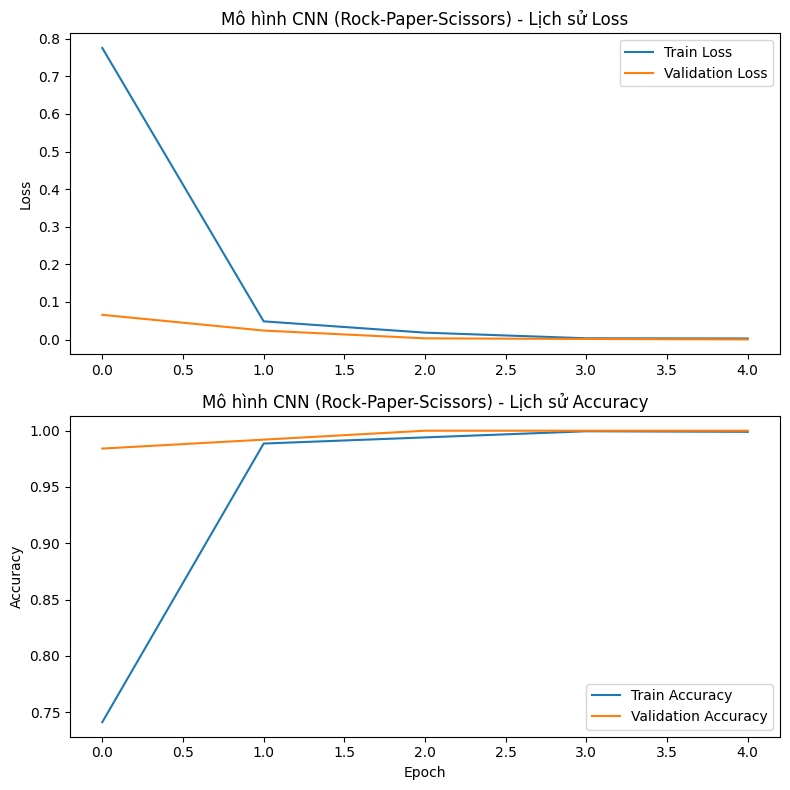

--- Đang vẽ Ma trận nhầm lẫn cho Mô hình CNN (Rock-Paper-Scissors) ---
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step


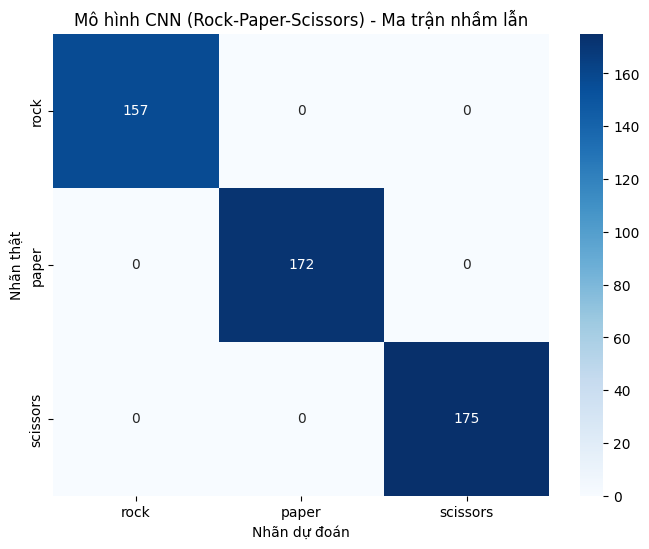

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# --- Hàm trợ giúp cho Cell 1 ---
def plot_history(history, model_name):
    """Vẽ biểu đồ Lịch sử Loss và Accuracy."""
    print(f"\n--- Đang vẽ biểu đồ Lịch sử cho {model_name} ---")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
    
    # Plot Lịch sử Loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{model_name} - Lịch sử Loss')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot Lịch sử Accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'{model_name} - Lịch sử Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, val_dataset, class_names, model_name):
    """Vẽ Ma trận nhầm lẫn."""
    print(f"--- Đang vẽ Ma trận nhầm lẫn cho {model_name} ---")
    y_true = np.concatenate([y for x, y in val_dataset], axis=0)
    y_pred_probs = model.predict(val_dataset)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Ma trận nhầm lẫn')
    plt.xlabel('Nhãn dự đoán')
    plt.ylabel('Nhãn thật')
    plt.show()

# --- 1. Tải dữ liệu ---
print("--- [Mô hình 1] Đang tải bộ dữ liệu 'rock_paper_scissors' ---")
(ds_train_cnn, ds_val_cnn), ds_info_cnn = tfds.load(
    'rock_paper_scissors',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)
NUM_CLASSES_CNN = ds_info_cnn.features['label'].num_classes
CLASS_NAMES_CNN = ds_info_cnn.features['label'].names
print(f"Đã tải xong. Số lớp: {NUM_CLASSES_CNN}, Tên: {CLASS_NAMES_CNN}")

# --- 2. Tiền xử lý ---
IMG_HEIGHT_CNN = 180
IMG_WIDTH_CNN = 180
BATCH_SIZE_CNN = 32

def preprocess_cnn(image, label):
    image = tf.image.resize(image, [IMG_HEIGHT_CNN, IMG_WIDTH_CNN])
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
train_ds_cnn = (
    ds_train_cnn
    .map(preprocess_cnn).cache().shuffle(1000)
    .batch(BATCH_SIZE_CNN).prefetch(buffer_size=AUTOTUNE)
)
val_ds_cnn = (
    ds_val_cnn
    .map(preprocess_cnn).cache()
    .batch(BATCH_SIZE_CNN).prefetch(buffer_size=AUTOTUNE)
)

# --- 3. Xây dựng mô hình CNN ---
model_cnn = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT_CNN, IMG_WIDTH_CNN, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(NUM_CLASSES_CNN, activation='softmax') 
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# --- 4. Huấn luyện và Đánh giá ---
print("\n--- [Mô hình 1] Bắt đầu huấn luyện CNN ---")
history_cnn = model_cnn.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=5 # Huấn luyện 5 epochs cho nhanh
)
print("--- [Mô hình 1] Đã hoàn tất huấn luyện! ---")

# --- 5. Vẽ biểu đồ ---
plot_history(history_cnn, "Mô hình CNN (Rock-Paper-Scissors)")
plot_confusion_matrix(model_cnn, val_ds_cnn, CLASS_NAMES_CNN, "Mô hình CNN (Rock-Paper-Scissors)")

--- [Mô hình CNN] Đang tải bộ dữ liệu 'rock_paper_scissors' ---
Đã tải xong. Số lớp: 3, Tên: ['rock', 'paper', 'scissors']

--- [Mô hình CNN] Bắt đầu huấn luyện ---
Epoch 1/5


c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 808ms/step - accuracy: 0.7004 - loss: 0.8674 - val_accuracy: 0.9484 - val_loss: 0.1667
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 50s 790ms/step - accuracy: 0.9836 - loss: 0.0601 - val_accuracy: 0.9960 - val_loss: 0.0136
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 48s 767ms/step - accuracy: 0.9970 - loss: 0.0113 - val_accuracy: 0.9980 - val_loss: 0.0060
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 50s 795ms/step - accuracy: 0.9990 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 8.0824e-04
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 593ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 7.8654e-04
--- [Mô hình CNN] Đã hoàn tất huấn luyện! ---

--- Đang vẽ 4 biểu đồ chi tiết cho Mô hình CNN (Rock-Paper-Scissors) ---


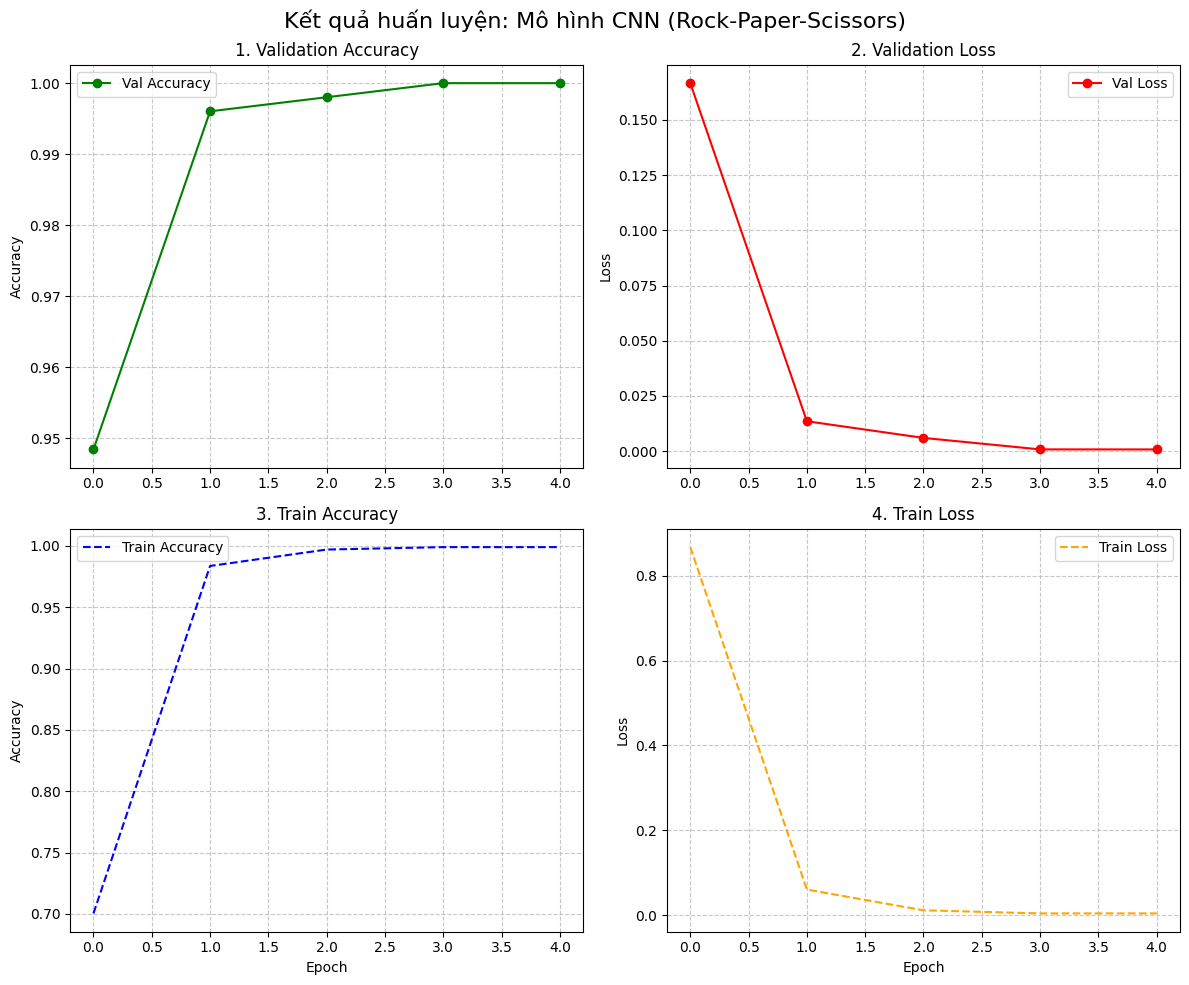

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# --- Hàm vẽ 4 biểu đồ riêng biệt (Chỉ vẽ biểu đồ) ---
def plot_history_4_charts(history, model_name):
    """
    Vẽ 4 biểu đồ riêng biệt: 
    1. Validation Accuracy
    2. Validation Loss
    3. Train Accuracy
    4. Train Loss
    """
    print(f"\n--- Đang vẽ 4 biểu đồ chi tiết cho {model_name} ---")
    
    # Tạo khung hình 2x2 (4 biểu đồ)
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Kết quả huấn luyện: {model_name}', fontsize=16)
    
    # Lấy dữ liệu
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    # --- Biểu đồ 1: Validation Accuracy ---
    axs[0, 0].plot(epochs_range, val_acc, label='Val Accuracy', color='green', marker='o')
    axs[0, 0].set_title('1. Validation Accuracy')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].grid(True, linestyle='--', alpha=0.7)
    axs[0, 0].legend()

    # --- Biểu đồ 2: Validation Loss ---
    axs[0, 1].plot(epochs_range, val_loss, label='Val Loss', color='red', marker='o')
    axs[0, 1].set_title('2. Validation Loss')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)
    axs[0, 1].legend()

    # --- Biểu đồ 3: Train Accuracy ---
    axs[1, 0].plot(epochs_range, acc, label='Train Accuracy', color='blue', linestyle='--')
    axs[1, 0].set_title('3. Train Accuracy')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('Accuracy')
    axs[1, 0].grid(True, linestyle='--', alpha=0.7)
    axs[1, 0].legend()

    # --- Biểu đồ 4: Train Loss ---
    axs[1, 1].plot(epochs_range, loss, label='Train Loss', color='orange', linestyle='--')
    axs[1, 1].set_title('4. Train Loss')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Loss')
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, val_dataset, class_names, model_name):
    """Vẽ Ma trận nhầm lẫn."""
    print(f"--- Đang vẽ Ma trận nhầm lẫn cho {model_name} ---")
    # Lấy dữ liệu từ dataset (batching)
    y_true = []
    y_pred_probs = []
    
    for images, labels in val_dataset:
        y_true.extend(labels.numpy())
        probs = model.predict(images)
        y_pred_probs.extend(probs)
        
    y_true = np.array(y_true)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Ma trận nhầm lẫn')
    plt.xlabel('Nhãn dự đoán')
    plt.ylabel('Nhãn thật')
    plt.show()

# --- 1. Tải dữ liệu (Rock Paper Scissors) ---
print("--- [Mô hình CNN] Đang tải bộ dữ liệu 'rock_paper_scissors' ---")
# Dataset này khoảng 450MB, split train 80/20 như yêu cầu
(ds_train_cnn, ds_val_cnn), ds_info_cnn = tfds.load(
    'rock_paper_scissors',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)
NUM_CLASSES_CNN = ds_info_cnn.features['label'].num_classes
CLASS_NAMES_CNN = ds_info_cnn.features['label'].names
print(f"Đã tải xong. Số lớp: {NUM_CLASSES_CNN}, Tên: {CLASS_NAMES_CNN}")

# --- 2. Tiền xử lý ---
IMG_HEIGHT_CNN = 180
IMG_WIDTH_CNN = 180
BATCH_SIZE_CNN = 32

def preprocess_cnn(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [IMG_HEIGHT_CNN, IMG_WIDTH_CNN])
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
train_ds_cnn = (
    ds_train_cnn
    .map(preprocess_cnn).cache().shuffle(1000)
    .batch(BATCH_SIZE_CNN).prefetch(buffer_size=AUTOTUNE)
)
val_ds_cnn = (
    ds_val_cnn
    .map(preprocess_cnn).cache()
    .batch(BATCH_SIZE_CNN).prefetch(buffer_size=AUTOTUNE)
)

# --- 3. Xây dựng mô hình CNN ---
model_cnn = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT_CNN, IMG_WIDTH_CNN, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(NUM_CLASSES_CNN, activation='softmax') 
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# --- 4. Huấn luyện và Đánh giá ---
print("\n--- [Mô hình CNN] Bắt đầu huấn luyện ---")
history_cnn = model_cnn.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=5 # Giữ nguyên 5 epochs
)
print("--- [Mô hình CNN] Đã hoàn tất huấn luyện! ---")

# --- 5. Vẽ biểu đồ (Chỉ vẽ 4 biểu đồ) ---
plot_history_4_charts(history_cnn, "Mô hình CNN (Rock-Paper-Scissors)")

Mô hình 2: Dự đoán Chuỗi thời gian (LSTM)
Nhiệm vụ: Dự đoán giá nhà trung bình tháng tiếp theo.

Giải pháp: Chúng ta sẽ tạo dữ liệu giả lập (mock data) cho dataset_timeseries.csv bằng NumPy và Pandas.


--- [Mô hình 2] Đang tạo dữ liệu chuỗi thời gian giả lập ---

--- [Mô hình 2] Bắt đầu huấn luyện LSTM ---


c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- [Mô hình 2] Đã hoàn tất huấn luyện! ---

--- Đang vẽ biểu đồ Lịch sử cho Mô hình LSTM (Hồi quy giá) ---


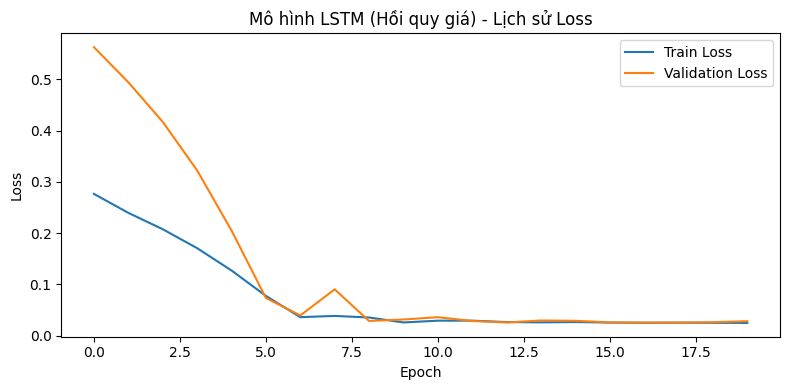

--- Đang vẽ Biểu đồ dự đoán cho Mô hình LSTM (Hồi quy giá) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


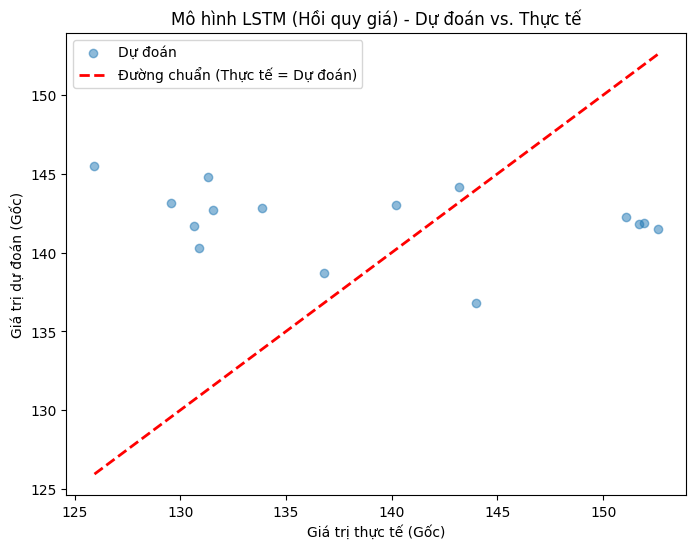

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# --- Hàm trợ giúp cho Cell 2 ---
def plot_history_regression(history, model_name):
    """Vẽ biểu đồ Lịch sử Loss (chỉ Loss)."""
    print(f"\n--- Đang vẽ biểu đồ Lịch sử cho {model_name} ---")
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Lịch sử Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_regression_results(model, X_test, y_test, scaler, model_name):
    """Vẽ biểu đồ Dự đoán vs. Thực tế cho mô hình Hồi quy."""
    print(f"--- Đang vẽ Biểu đồ dự đoán cho {model_name} ---")
    
    y_pred_scaled = model.predict(X_test)
    
    # Chuyển về giá trị gốc
    y_pred_orig = scaler.inverse_transform(y_pred_scaled)
    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_orig, y_pred_orig, alpha=0.5, label='Dự đoán')
    # Vẽ đường y=x
    plt.plot([min(y_test_orig), max(y_test_orig)], [min(y_test_orig), max(y_test_orig)], 'r--', lw=2, label='Đường chuẩn (Thực tế = Dự đoán)')
    plt.title(f'{model_name} - Dự đoán vs. Thực tế')
    plt.xlabel('Giá trị thực tế (Gốc)')
    plt.ylabel('Giá trị dự đoán (Gốc)')
    plt.legend()
    plt.show()

# --- 1. Tạo dữ liệu giả lập ---
print("\n--- [Mô hình 2] Đang tạo dữ liệu chuỗi thời gian giả lập ---")
dates = pd.date_range(start='2018-01', end='2024-12', freq='MS')
prices = 100 + np.arange(len(dates)) * 0.5 + np.random.randn(len(dates)) * 5 + np.sin(np.arange(len(dates)) * 0.5) * 10
ts_df = pd.DataFrame({'Thang': dates, 'GiaTrungBinh': prices})
ts_df = ts_df.set_index('Thang')
data_ts = ts_df['GiaTrungBinh'].values.reshape(-1, 1)

# --- 2. Tiền xử lý ---
scaler_ts = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler_ts.fit_transform(data_ts)

def create_sequences(dataset, look_back=12):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

LOOK_BACK = 12
X_ts, y_ts = create_sequences(data_scaled, LOOK_BACK)
X_ts = np.reshape(X_ts, (X_ts.shape[0], X_ts.shape[1], 1))
train_size = int(len(X_ts) * 0.8)
X_train_ts, X_test_ts = X_ts[:train_size], X_ts[train_size:]
y_train_ts, y_test_ts = y_ts[:train_size], y_ts[train_size:]

# --- 3. Xây dựng mô hình LSTM ---
model_lstm = keras.Sequential([
    layers.LSTM(50, activation='relu', input_shape=(LOOK_BACK, 1), return_sequences=True),
    layers.LSTM(50, activation='relu', return_sequences=False),
    layers.Dense(25, activation='relu'),
    layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# --- 4. Huấn luyện và Đánh giá ---
print("\n--- [Mô hình 2] Bắt đầu huấn luyện LSTM ---")
history_lstm = model_lstm.fit(
    X_train_ts,
    y_train_ts,
    epochs=20,
    batch_size=16,
    validation_data=(X_test_ts, y_test_ts),
    verbose=0
)
print("--- [Mô hình 2] Đã hoàn tất huấn luyện! ---")

# --- 5. Vẽ biểu đồ ---
plot_history_regression(history_lstm, "Mô hình LSTM (Hồi quy giá)")
plot_regression_results(model_lstm, X_test_ts, y_test_ts, scaler_ts, "Mô hình LSTM (Hồi quy giá)")

Cell 3: Mô hình 3 (Transfer Learning)
Cell này sẽ tải bộ dữ liệu "Horses or Humans" (giả lập 2 lớp ảnh mới), huấn luyện mô hình VGG16 (đã đóng băng), sau đó vẽ biểu đồ val_loss/val_accuracy và ma trận nhầm lẫn.

c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Trinh Gia Bao\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at


--- [Mô hình 3] Đang tải bộ dữ liệu 'horses_or_humans' ---
Đã tải xong. Số lớp: 2, Tên: ['horses', 'humans']

--- [Mô hình 3] Bắt đầu huấn luyện (Transfer Learning) ---
Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 190s 6s/step - accuracy: 0.7118 - loss: 1.0098 - val_accuracy: 0.9258 - val_loss: 0.1999
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 126s 4s/step - accuracy: 0.8997 - loss: 0.3222 - val_accuracy: 0.9727 - val_loss: 0.0655
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 194s 6s/step - accuracy: 0.9445 - loss: 0.1537 - val_accuracy: 0.9844 - val_loss: 0.0415
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 195s 6s/step - accuracy: 0.9611 - loss: 0.0971 - val_accuracy: 0.9805 - val_loss: 0.0473
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.9757 - loss: 0.0625 - val_accuracy: 0.9844 - val_loss: 0.0415
--- [Mô hình 3] Đã hoàn tất huấn luyện! ---

--- Đang vẽ biểu đồ Lịch sử cho Mô hình Transfer Learning (Horses or Humans) ---


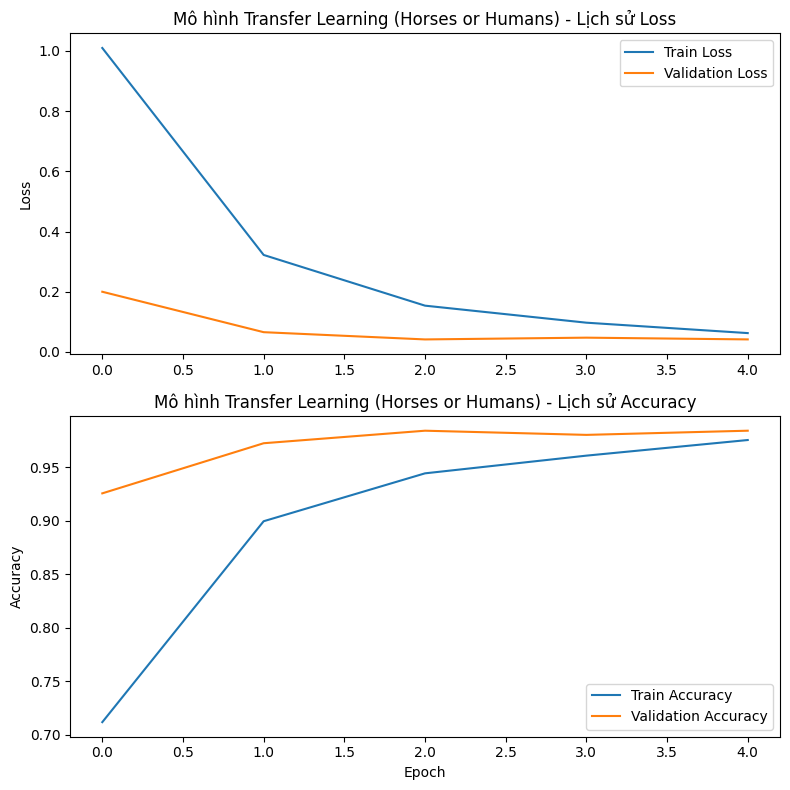

--- Đang vẽ Ma trận nhầm lẫn cho Mô hình Transfer Learning (Horses or Humans) ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step


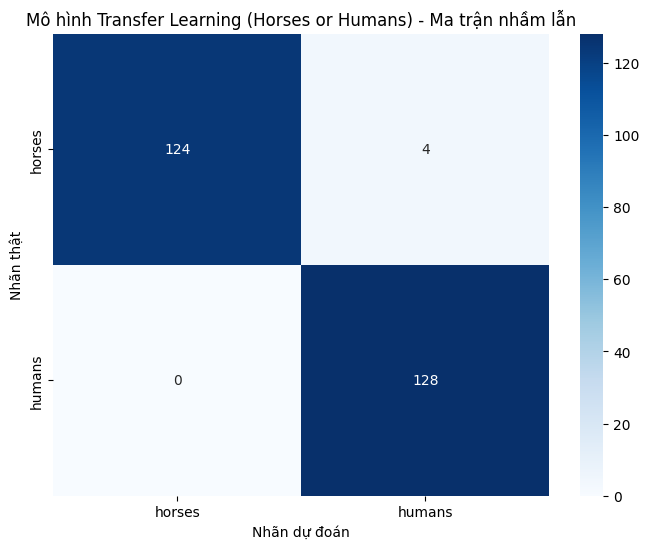

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# --- Hàm trợ giúp cho Cell 3 (Giữ nguyên) ---
def plot_history(history, model_name):
    """Vẽ biểu đồ Lịch sử Loss và Accuracy."""
    print(f"\n--- Đang vẽ biểu đồ Lịch sử cho {model_name} ---")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
    
    # Plot Lịch sử Loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{model_name} - Lịch sử Loss')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot Lịch sử Accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'{model_name} - Lịch sử Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, val_dataset, class_names, model_name):
    """Vẽ Ma trận nhầm lẫn."""
    print(f"--- Đang vẽ Ma trận nhầm lẫn cho {model_name} ---")
    y_true = np.concatenate([y for x, y in val_dataset], axis=0)
    y_pred_probs = model.predict(val_dataset)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten() # Cho phân loại nhị phân
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Ma trận nhầm lẫn')
    plt.xlabel('Nhãn dự đoán')
    plt.ylabel('Nhãn thật')
    plt.show()

# --- 1. Tải dữ liệu ---
# Dùng 'horses_or_humans' để tránh lỗi của 'cats_vs_dogs'
print("\n--- [Mô hình 3] Đang tải bộ dữ liệu 'horses_or_humans' ---")
(ds_train_tl, ds_val_tl), ds_info_tl = tfds.load(
    'horses_or_humans', 
    split=['train', 'test'], 
    as_supervised=True,
    with_info=True,
)
NUM_CLASSES_TL = ds_info_tl.features['label'].num_classes
CLASS_NAMES_TL = ds_info_tl.features['label'].names
print(f"Đã tải xong. Số lớp: {NUM_CLASSES_TL}, Tên: {CLASS_NAMES_TL}")

# --- 2. Tiền xử lý (Giữ nguyên) ---
IMG_HEIGHT_VGG = 224
IMG_WIDTH_VGG = 224
BATCH_SIZE_VGG = 32

def preprocess_vgg(image, label):
    image = tf.image.resize(image, [IMG_HEIGHT_VGG, IMG_WIDTH_VGG])
    image = tf.keras.applications.vgg16.preprocess_input(image) 
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
train_ds_tl = (
    ds_train_tl
    .map(preprocess_vgg).cache()
    .batch(BATCH_SIZE_VGG).prefetch(buffer_size=AUTOTUNE)
)
val_ds_tl = (
    ds_val_tl
    .map(preprocess_vgg).cache()
    .batch(BATCH_SIZE_VGG).prefetch(buffer_size=AUTOTUNE)
)

# --- 3. Xây dựng mô hình ---
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT_VGG, IMG_WIDTH_VGG, 3)
)
base_model.trainable = False # Đóng băng

inputs = keras.Input(shape=(IMG_HEIGHT_VGG, IMG_WIDTH_VGG, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
# <--- SỬA LỖI Ở ĐÂY ---
# Thêm (x) để gọi layer Dropout với đầu vào là x
x = layers.Dropout(0.5)(x) 
# <--- KẾT THÚC SỬA LỖI ---
outputs = layers.Dense(1, activation='sigmoid')(x) # 1 nơ-ron + sigmoid cho 2 lớp
model_transfer = keras.Model(inputs, outputs)

model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy', # Dùng binary_crossentropy cho 2 lớp
    metrics=['accuracy']
)

# --- 4. Huấn luyện và Đánh giá ---
print("\n--- [Mô hình 3] Bắt đầu huấn luyện (Transfer Learning) ---")
history_transfer = model_transfer.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=5
)
print("--- [Mô hình 3] Đã hoàn tất huấn luyện! ---")

# --- 5. Vẽ biểu đồ ---
plot_history(history_transfer, "Mô hình Transfer Learning (Horses or Humans)")
plot_confusion_matrix(model_transfer, val_ds_tl, CLASS_NAMES_TL, "Mô hình Transfer Learning (Horses or Humans)")

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4925 - loss: 0.7316 - val_accuracy: 0.5300 - val_loss: 0.6945
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5250 - loss: 0.6876 - val_accuracy: 0.4700 - val_loss: 0.7021
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5225 - loss: 0.6962 - val_accuracy: 0.4800 - val_loss: 0.6944
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5750 - loss: 0.6863 - val_accuracy: 0.5100 - val_loss: 0.6935
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5525 - loss: 0.6853 - val_accuracy: 0.4900 - val_loss: 0.6954
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7050 - loss: 0.6764 - val_accuracy: 0.4200 - val_loss: 0.6962
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6225 - loss: 0.6687 - val_accuracy: 0.4700 - val_loss: 0.6986
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6100 - loss: 0.6632 - val_accuracy: 0.4800 - v

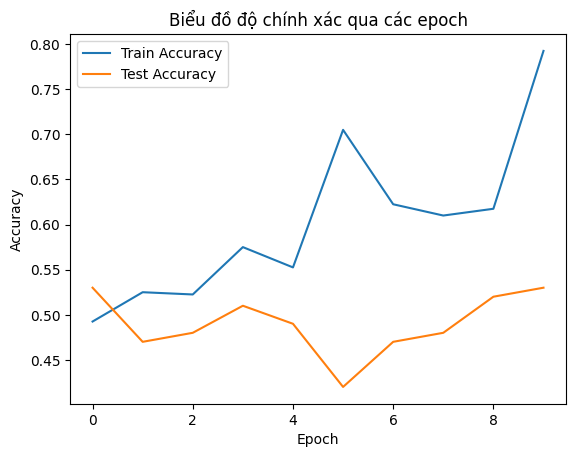

In [ ]:
# =======================
# BÀI 3: FINE-TUNE MÔ HÌNH HỌC SÂU (DEMO)
# =======================

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

num_samples = 500
img_height, img_width = 32, 32
num_classes = 2

# Tạo dữ liệu ngẫu nhiên
X = np.random.rand(num_samples, img_height, img_width, 3)
y = np.random.randint(0, num_classes, num_samples)

# Chia dữ liệu train/test
X_train, X_test = X[:400], X[400:]
y_train, y_test = y[:400], y[400:]

# ✅ 2. Xây dựng mô hình CNN đơn giản
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# ✅ 3. Biên dịch mô hình
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ✅ 4. Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), verbose=1)

# ✅ 5. Đánh giá mô hình
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Độ chính xác trên tập kiểm tra: {test_acc:.4f}")

# ✅ 6. Vẽ biểu đồ Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Biểu đồ độ chính xác qua các epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()